In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/.shortcut-targets-by-id/1ff_P_d5eKt3FHTBeVsnIuxlBkYMyohCY/image_classification')

['DATA', 'imagenet_classes.txt', 'image_classification.ipynb']

In [ ]:
%cd /content/drive/.shortcut-targets-by-id/1ff_P_d5eKt3FHTBeVsnIuxlBkYMyohCY/image_classification

/content/drive/.shortcut-targets-by-id/1ff_P_d5eKt3FHTBeVsnIuxlBkYMyohCY/image_classification


In [ ]:
from pathlib import Path

DATA_ROOT = Path(r"/content/drive/MyDrive/image_classification/DATA")
IMG_EXTS = { ".jpg" }

for split in ["train", "validation", "test"]:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        continue
    print(f"\n{split}/")
    for cls_dir in sorted(split_dir.iterdir()):
        imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in IMG_EXTS]
        print(f"  {cls_dir.name:20s}: {len(imgs):>5} images")


train/
  bikini              :   448 images
  bra                 :   444 images
  dress               :   241 images
  longsleeve          :   455 images
  outwear             :   184 images
  pants               :   468 images
  shirt               :   290 images
  shorts              :   202 images
  skirt               :   112 images
  t-shirt             :   795 images
  underwear           :   398 images

validation/
  bikini              :    56 images
  bra                 :    55 images
  dress               :    32 images
  longsleeve          :    49 images
  outwear             :    24 images
  pants               :    49 images
  shirt               :    29 images
  shorts              :    25 images
  skirt               :    12 images
  t-shirt             :    81 images
  underwear           :    48 images

test/
  bikini              :    56 images
  bra                 :    57 images
  dress               :    15 images
  longsleeve          :    72 images
  outwear 

In [ ]:
from PIL import Image
import numpy as np

# Load an image
img = Image.open(f'{DATA_ROOT}/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')

# Resize to target size
img = img.resize((224, 224))

# Convert to numpy array
x = np.array(img)
print(x.shape)

(224, 224, 3)


### Pre-trained (mobilenetv2)

In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
import numpy as np

# Load pre-trained model
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval()

# Preprocessing for MobileNetV2
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 194MB/s]


In [ ]:
img = Image.open(f'{DATA_ROOT}/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)

# Make prediction
with torch.no_grad():
    output = model(batch_t)

# Get top predictions
_, indices = torch.sort(output, descending=True)

In [ ]:
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt -O imagenet_classes.txt

# Load ImageNet class names
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

# Get top 5 predictions
top5_indices = indices[0, :5].tolist()
top5_classes = [categories[i] for i in top5_indices]

print("Top 5 predictions:")
for i, class_name in enumerate(top5_classes):
    print(f"{i+1}: {class_name}")

--2026-03-07 08:04:14--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0.001s  

2026-03-07 08:04:15 (15.7 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]

Top 5 predictions:
1: jean
2: suit
3: cardigan
4: sweatshirt
5: overskirt


## Transfer learning

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image

class ClothingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_path = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = { cls: i for i, cls in enumerate(self.classes) }

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_path.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_path)

    def __getitem__(self, index):
        img_path = self.image_path[index]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from torchvision import transforms

input_size = 224

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
from torch.utils.data import DataLoader

train_path = f'{DATA_ROOT}/train'
val_path = f'{DATA_ROOT}/validation'

train_dataset = ClothingDataset(
    data_dir=train_path,
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir=val_path,
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [5]:
import torch.nn as nn
import torchvision.models as models

class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, num_classes=11):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

In [6]:
import torch
import torch.optim as optim

device = 'cuda'

model = ClothingClassifierMobileNet(num_classes=11)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 178MB/s]


In [ ]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels  = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch + 1} / {num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

In [ ]:
def train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    ckps_root = '/content/drive/MyDrive/image_classification/checkpoints'
    os.makedirs(ckps_root, exist_ok=True)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels  = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch + 1} / {num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            checkpoint_path = f'{ckps_root}/mobilenet_v2_{epoch + 1:02d}_{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'#! Checkpoint saved: {checkpoint_path}')

In [ ]:
def make_model(lr=0.01):
    model = ClothingClassifierMobileNet()
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, optimizer

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
num_epochs = 10

for lr in learning_rates:
    print(f'\n=== Learning Rate: {lr} ===')
    model, optimizer = make_model(lr=lr)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


=== Learning Rate: 0.0001 ===
Epoch 1 / 10
  Train Loss: 2.0669, Train Acc: 0.3215
  Val Loss: 1.8160, Val Acc: 0.4500
Epoch 2 / 10
  Train Loss: 1.7010, Train Acc: 0.5056
  Val Loss: 1.5136, Val Acc: 0.5717
Epoch 3 / 10
  Train Loss: 1.4660, Train Acc: 0.5878
  Val Loss: 1.3337, Val Acc: 0.6196
Epoch 4 / 10
  Train Loss: 1.3108, Train Acc: 0.6460
  Val Loss: 1.2002, Val Acc: 0.6457
Epoch 5 / 10
  Train Loss: 1.1857, Train Acc: 0.6795
  Val Loss: 1.0995, Val Acc: 0.6870
Epoch 6 / 10
  Train Loss: 1.1122, Train Acc: 0.6914
  Val Loss: 1.0096, Val Acc: 0.7043
Epoch 7 / 10
  Train Loss: 1.0365, Train Acc: 0.7139
  Val Loss: 0.9715, Val Acc: 0.7370
Epoch 8 / 10
  Train Loss: 0.9820, Train Acc: 0.7280
  Val Loss: 0.9053, Val Acc: 0.7435
Epoch 9 / 10
  Train Loss: 0.9377, Train Acc: 0.7374
  Val Loss: 0.8680, Val Acc: 0.7500
Epoch 10 / 10
  Train Loss: 0.8783, Train Acc: 0.7610
  Val Loss: 0.8447, Val Acc: 0.7543

=== Learning Rate: 0.001 ===
Epoch 1 / 10
  Train Loss: 1.4367, Train Acc: 0.

### Adding Inner Layers

In [ ]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=11):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
def make_model(lr=0.001, size_inner=100):
    model = ClothingClassifierMobileNet(
        num_classes=11,
        size_inner=size_inner
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, optimizer

In [ ]:
size_inners = [10, 100, 1000]
num_epochs = 10

for size_inner in size_inners:
    print(f"\n--- Size Inner: {size_inner} ---")
    model, optimizer = make_model(lr=0.001, size_inner=size_inner)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


--- Size Inner: 10 ---
Epoch 1 / 10
  Train Loss: 1.9541, Train Acc: 0.3520
  Val Loss: 1.5937, Val Acc: 0.4826
Epoch 2 / 10
  Train Loss: 1.5035, Train Acc: 0.5214
  Val Loss: 1.3548, Val Acc: 0.5326
Epoch 3 / 10
  Train Loss: 1.3340, Train Acc: 0.5613
  Val Loss: 1.2552, Val Acc: 0.5826
Epoch 4 / 10
  Train Loss: 1.2371, Train Acc: 0.5811
  Val Loss: 1.2081, Val Acc: 0.5804
Epoch 5 / 10
  Train Loss: 1.1999, Train Acc: 0.5908
  Val Loss: 1.1410, Val Acc: 0.6065
Epoch 6 / 10
  Train Loss: 1.1317, Train Acc: 0.6099
  Val Loss: 1.1329, Val Acc: 0.5913
Epoch 7 / 10
  Train Loss: 1.1320, Train Acc: 0.6054
  Val Loss: 1.1045, Val Acc: 0.5957
Epoch 8 / 10
  Train Loss: 1.0758, Train Acc: 0.6188
  Val Loss: 1.0644, Val Acc: 0.6239
Epoch 9 / 10
  Train Loss: 1.0512, Train Acc: 0.6287
  Val Loss: 1.0525, Val Acc: 0.6239
Epoch 10 / 10
  Train Loss: 1.0465, Train Acc: 0.6411
  Val Loss: 1.0327, Val Acc: 0.6391

--- Size Inner: 100 ---
Epoch 1 / 10
  Train Loss: 1.2984, Train Acc: 0.5848
  Val L

### Dropout Regularization

In [8]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=11):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output_layer(x)
        return x

In [ ]:
def make_model(lr=.001, size_inner=100, droprate=0.2):
    model = ClothingClassifierMobileNet(
        num_classes=11,
        size_inner=size_inner,
        droprate=droprate
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, optimizer

In [ ]:
num_epochs = 10

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(f"\n--- droprate: {droprate} ---")
    model, optimizer = make_model(lr=0.001, size_inner=100, droprate=droprate)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)


--- droprate: 0.0 ---
Epoch 1 / 10
  Train Loss: 1.3582, Train Acc: 0.5623
  Val Loss: 0.8185, Val Acc: 0.7348
Epoch 2 / 10
  Train Loss: 0.8105, Train Acc: 0.7345
  Val Loss: 0.6934, Val Acc: 0.7826
Epoch 3 / 10
  Train Loss: 0.6828, Train Acc: 0.7714
  Val Loss: 0.6834, Val Acc: 0.7978
Epoch 4 / 10
  Train Loss: 0.6321, Train Acc: 0.7838
  Val Loss: 0.6230, Val Acc: 0.8000
Epoch 5 / 10
  Train Loss: 0.5476, Train Acc: 0.8088
  Val Loss: 0.5924, Val Acc: 0.7978
Epoch 6 / 10
  Train Loss: 0.5245, Train Acc: 0.8140
  Val Loss: 0.6004, Val Acc: 0.7913
Epoch 7 / 10
  Train Loss: 0.4973, Train Acc: 0.8308
  Val Loss: 0.6178, Val Acc: 0.7891
Epoch 8 / 10
  Train Loss: 0.4814, Train Acc: 0.8407
  Val Loss: 0.6404, Val Acc: 0.7957
Epoch 9 / 10
  Train Loss: 0.4479, Train Acc: 0.8462
  Val Loss: 0.6780, Val Acc: 0.7826
Epoch 10 / 10
  Train Loss: 0.4402, Train Acc: 0.8472
  Val Loss: 0.6457, Val Acc: 0.7870

--- droprate: 0.2 ---
Epoch 1 / 10
  Train Loss: 1.4556, Train Acc: 0.5197
  Val Loss

### Train with checkpointing

In [ ]:
model, optimizer = make_model(lr=0.001, size_inner=100, droprate=0.2)
train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device)

Epoch 1 / 10
  Train Loss: 1.4539, Train Acc: 0.5291
  Val Loss: 0.9270, Val Acc: 0.7065
#! Checkpoint saved: /content/drive/MyDrive/image_classification/checkpoints/mobilenet_v2_01_0.707.pth
Epoch 2 / 10
  Train Loss: 0.9019, Train Acc: 0.7072
  Val Loss: 0.7535, Val Acc: 0.7370
#! Checkpoint saved: /content/drive/MyDrive/image_classification/checkpoints/mobilenet_v2_02_0.737.pth
Epoch 3 / 10
  Train Loss: 0.7705, Train Acc: 0.7449
  Val Loss: 0.6640, Val Acc: 0.8022
#! Checkpoint saved: /content/drive/MyDrive/image_classification/checkpoints/mobilenet_v2_03_0.802.pth
Epoch 4 / 10
  Train Loss: 0.6859, Train Acc: 0.7706
  Val Loss: 0.6211, Val Acc: 0.8109
#! Checkpoint saved: /content/drive/MyDrive/image_classification/checkpoints/mobilenet_v2_04_0.811.pth
Epoch 5 / 10
  Train Loss: 0.6405, Train Acc: 0.7763
  Val Loss: 0.6540, Val Acc: 0.7783
Epoch 6 / 10
  Train Loss: 0.6119, Train Acc: 0.7860
  Val Loss: 0.5953, Val Acc: 0.8109
Epoch 7 / 10
  Train Loss: 0.5833, Train Acc: 0.8068
 

### Using the Trained Model

In [10]:
import glob
import os

list_of_files = glob.glob('/content/drive/MyDrive/image_classification/checkpoints/mobilenet_v2_*.pth')
latest_file = max(list_of_files, key=os.path.getctime)
print(f"Loading model from: {latest_file}")

# Load model
model = ClothingClassifierMobileNet(size_inner=100, droprate=0.2, num_classes=11)
model.load_state_dict(torch.load(latest_file))
model.to(device)
model.eval()

Loading model from: /content/drive/MyDrive/image_classification/checkpoints/mobilenet_v2_09_0.820.pth


ClothingClassifierMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16,

In [12]:
!pip install -q keras_image_helper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


In [13]:
from keras_image_helper import create_preprocessor
import numpy as np

def preprocess_pytorch_style(X):
    X = X / 255.0

    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1)

    X = X.transpose(0, 3, 1, 2)

    X = (X - mean) / std
    return X.astype(np.float32)

In [14]:
preprocessor = create_preprocessor(preprocess_pytorch_style, target_size=(224, 224))

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT3DUy2YtGR8AN35l0PsepNr4_E3tNT8YOzjA&s"
X = preprocessor.from_url(url)
X = torch.Tensor(X).to(device)

with torch.no_grad():
    pred = model(X).cpu().numpy()[0]

classes = [
    "bikini", "bra", "dress", "longsleeve", "outwear", "pants",
    "shirt", "shorts", "skirt", "t-shirt", "underwear"
]

result = dict(zip(classes, pred.tolist()))
result

{'bikini': 3.2917394638061523,
 'bra': -3.413743734359741,
 'dress': -4.268299579620361,
 'longsleeve': -5.75558614730835,
 'outwear': -7.264216899871826,
 'pants': -0.7827052474021912,
 'shirt': -9.467307090759277,
 'shorts': 2.1902503967285156,
 'skirt': -0.7051870226860046,
 't-shirt': -1.2295440435409546,
 'underwear': 10.338107109069824}

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import io
import requests
import torch.nn.functional as F

def predict_image_from_url(image_url, model, preprocessor, classes, device):
    # Load the image from URL
    response = requests.get(image_url)
    img_raw = Image.open(io.BytesIO(response.content)).convert('RGB')

    X = preprocessor.from_url(image_url)
    X = torch.Tensor(X).to(device)

    with torch.no_grad():
        logits = model(X)
        probabilities = F.softmax(logits, dim=1).cpu().numpy()[0] # Apply softmax

    results = dict(zip(classes, probabilities.tolist()))

    # Get the top prediction
    top_class = max(results, key=results.get)
    top_percentage = results[top_class] * 100 # Convert to percentage

    # Display the image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img_raw)
    plt.title(f"Prediction: {top_class} ({top_percentage:.2f}%)") # Update title
    plt.axis('off')
    plt.show()

    print(f"All predictions for image from URL: {image_url}")
    for cls_name, prob in sorted(results.items(), key=lambda item: item[1], reverse=True):
        print(f"  {cls_name}: {prob:.2%}") # Print as percentage

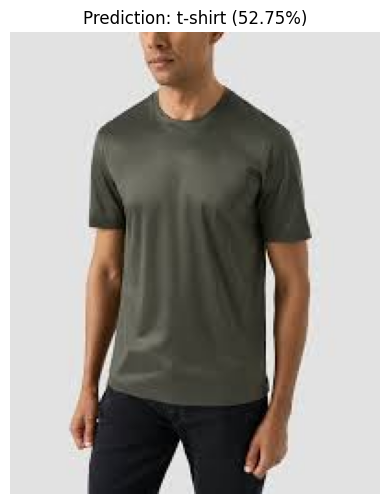

All predictions for image from URL: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSwX2vRn4H8lA1ace9kHApugNbtNvlaRczcOw&s
  t-shirt: 52.75%
  bra: 21.37%
  dress: 19.15%
  longsleeve: 4.50%
  underwear: 0.99%
  pants: 0.91%
  shirt: 0.09%
  bikini: 0.06%
  outwear: 0.06%
  shorts: 0.06%
  skirt: 0.05%


In [37]:
test_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSwX2vRn4H8lA1ace9kHApugNbtNvlaRczcOw&s"
predict_image_from_url(test_url, model, preprocessor, classes, device)

### Export to ONNX

In [17]:
!pip install onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 17.2 MB/s eta 0:00:00


In [38]:
import os

dummy_input = torch.randn(1, 3, 224, 224).to(device)

onnx_path = "/content/drive/MyDrive/image_classification/model/clothing_classifier_moblienet_v2.onnx"

# Create the directory if it doesn't exist
onnx_dir = os.path.dirname(onnx_path)
os.makedirs(onnx_dir, exist_ok=True)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    verbose=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Model exported to {onnx_path}")

/tmp/ipykernel_1946/4279029709.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0307 13:01:35.325000 1946 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0307 13:01:35.334000 1946 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0307 13:01:35.341000 1946 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1

[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 105 of general pattern rewrite rules.
Model exported to /content/drive/MyDrive/image_classification/model/clothing_classifier_moblienet_v2.onnx
